In [1]:
import os
import torch
from obd import utils,engine
import importlib
importlib.reload(utils)
importlib.reload(engine)
import torchvision
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision.utils import draw_bounding_boxes,draw_segmentation_masks
from torchvision.transforms import v2 as T
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

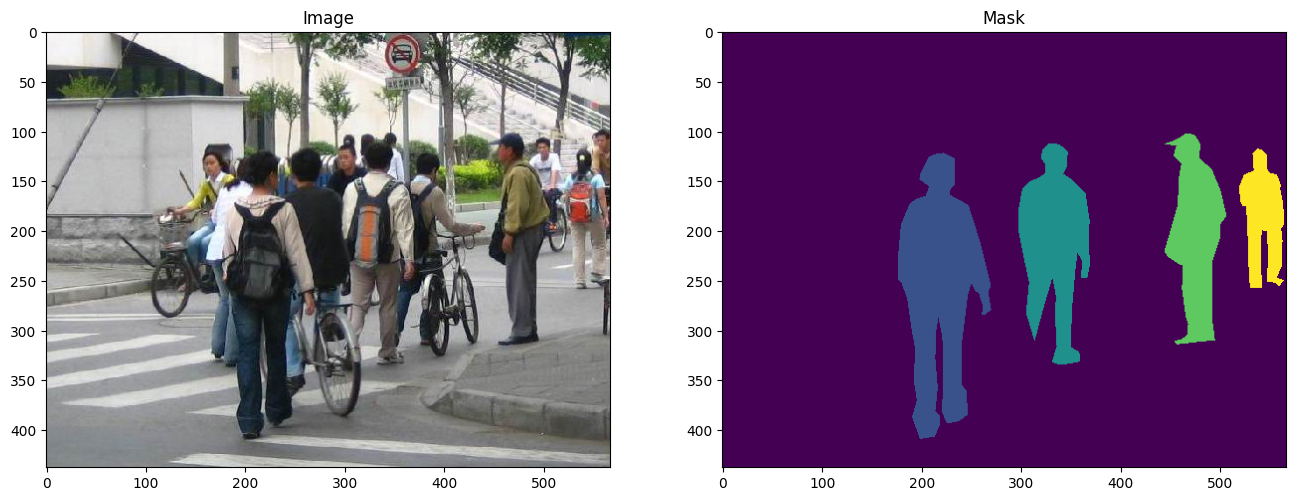

In [2]:
## Data Visualization
image = read_image("Datasets/PennFudanPed/PNGImages/FudanPed00046.png")
mask = read_image("Datasets/PennFudanPed/PedMasks/FudanPed00046_mask.png")

plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.title("Image")
plt.imshow(image.permute(1, 2, 0))
plt.subplot(122)
plt.title("Mask")
plt.imshow(mask.permute(1, 2, 0))
plt.show()

In [3]:
## Dataset Class
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        
        img = read_image(img_path)
        mask = read_image(mask_path)

        obj_ids = torch.unique(mask)[1:]  # Remove background (0)
        num_objs = len(obj_ids)

        # Create binary masks for each object
        masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)
        boxes = masks_to_boxes(masks)
        
        labels = torch.ones((num_objs,), dtype=torch.int64)
        image_id = idx
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        is_crowd = torch.zeros((num_objs,), dtype=torch.int64)

        # Wrap in Torchvision TV Tensors
        img = tv_tensors.Image(img)
        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img)),
            "masks": tv_tensors.Mask(masks),
            "labels": labels,
            "image_id": torch.tensor([image_id]),
            "area": area,
            "iscrowd": is_crowd
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

In [4]:
## Model Configurations

# Faster R-CNN with ResNet50
model_faster_rcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
num_classes = 2  # Background + Person
in_features = model_faster_rcnn.roi_heads.box_predictor.cls_score.in_features
model_faster_rcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Custom Faster R-CNN with MobileNetV2 Backbone
backbone = torchvision.models.mobilenet_v2(weights="DEFAULT").features
backbone.out_channels = 1280
anchor_gen = AnchorGenerator(sizes=((32, 64, 128, 256, 512),), aspect_ratios=((0.5, 1.0, 2.0),))
roi_pooler = torchvision.ops.MultiScaleRoIAlign(featmap_names=['0'], output_size=7, sampling_ratio=2)
model_custom_rcnn = FasterRCNN(backbone, num_classes=2, rpn_anchor_generator=anchor_gen, box_roi_pool=roi_pooler)

In [5]:
## Mask R-CNN Instance Segmentation Factory
def get_model_instance_segmentation(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
    
    # Box Predictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    # Mask Predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    
    return model

In [6]:
## Transforms and Data Loading

def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Split Dataset
full_dataset = PennFudanDataset('Datasets/PennFudanPed', get_transform(train=True))
indices = torch.randperm(len(full_dataset)).tolist()
train_dataset = torch.utils.data.Subset(full_dataset, indices[:-50])
test_dataset = torch.utils.data.Subset(PennFudanDataset('Datasets/PennFudanPed', get_transform(train=False)), indices[-50:])

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x))
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x))
)

In [7]:
## Training Setup
model = get_model_instance_segmentation(num_classes=2)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 2

In [ ]:
## Training Loop
for epoch in range(num_epochs):
    # Train for one epoch, printing status every 10 iterations
    # engine is typically imported from torchvision references
    engine.train_one_epoch(model, optimizer, train_loader, device, epoch, print_freq=10)
    
    # Update the learning rate
    lr_scheduler.step()
    
    # Evaluate on the test dataset
    engine.evaluate(model, test_loader, device=device)

print("That's it! Finally, we have a trained model.")

Epoch: [0]  [ 0/60]  eta: 0:32:12  lr: 0.000090  loss: 4.3285 (4.3285)  loss_classifier: 0.7372 (0.7372)  loss_box_reg: 0.0844 (0.0844)  loss_mask: 3.3644 (3.3644)  loss_objectness: 0.0950 (0.0950)  loss_rpn_box_reg: 0.0476 (0.0476)  time: 32.2006  data: 0.8401  max mem: 2428
Epoch: [0]  [10/60]  eta: 0:42:45  lr: 0.000936  loss: 1.2413 (2.1257)  loss_classifier: 0.4109 (0.4182)  loss_box_reg: 0.0795 (0.0854)  loss_mask: 1.0184 (1.5596)  loss_objectness: 0.0473 (0.0469)  loss_rpn_box_reg: 0.0062 (0.0156)  time: 51.3132  data: 0.5101  max mem: 3042
Epoch: [0]  [20/60]  eta: 0:35:01  lr: 0.001783  loss: 0.9478 (1.4405)  loss_classifier: 0.1066 (0.2601)  loss_box_reg: 0.0830 (0.0853)  loss_mask: 0.6889 (1.0413)  loss_objectness: 0.0326 (0.0376)  loss_rpn_box_reg: 0.0069 (0.0162)  time: 53.5580  data: 0.4665  max mem: 3042
Epoch: [0]  [30/60]  eta: 0:24:47  lr: 0.002629  loss: 0.5341 (1.1349)  loss_classifier: 0.0817 (0.2016)  loss_box_reg: 0.0856 (0.0838)  loss_mask: 0.3349 (0.8029)  loss

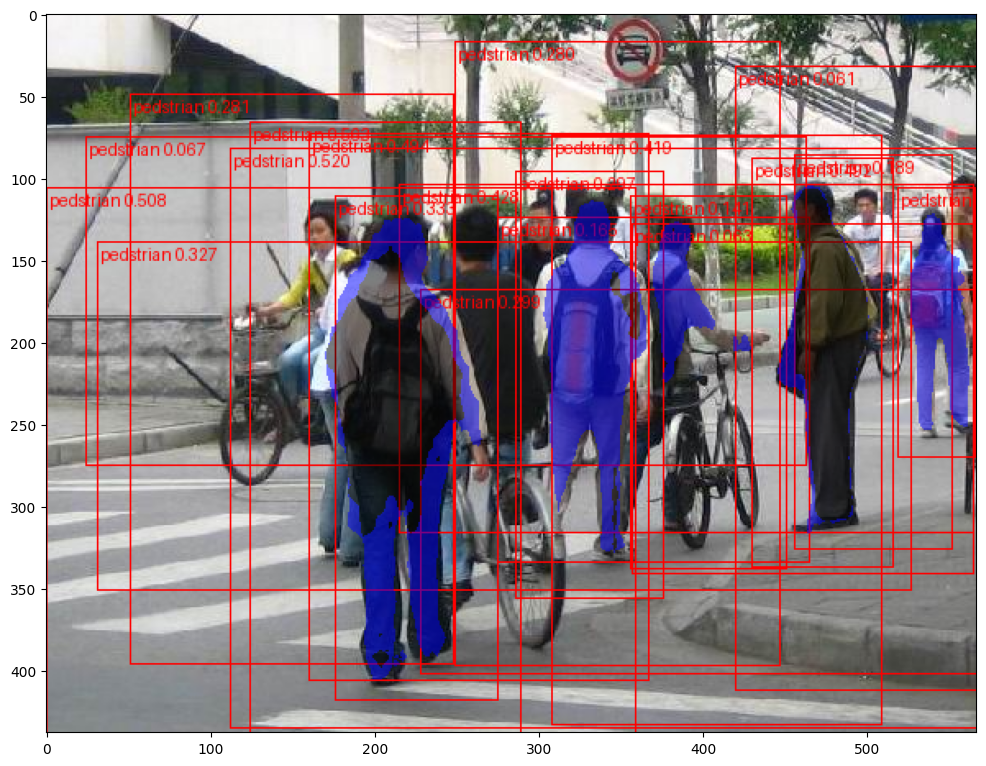

In [ ]:
## Testing and Visualization

eval_transform = get_transform(train=False)
model.eval()
with torch.no_grad():
    x = eval_transform(image)
    x = x[:3, ...].to(device)
    predictions = model([x])
    prediction = predictions[0]

# Pre-process original image 
image_display = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image_display = image_display[:3, ...]

# Prepare labels and boxes for visualization
pred_labels = [f"pedestrian {score:.3f}" for label, score in zip(prediction["labels"], prediction["scores"])]
pred_boxes = prediction["boxes"]

# Draw bounding boxes
output_image = torchvision.utils.draw_bounding_boxes(
    image_display, 
    pred_boxes, 
    labels=pred_labels, 
    colors="red"
)

# Prepare masks 
pred_masks = (prediction["masks"] > 0.7).squeeze(1)
output_image = torchvision.utils.draw_segmentation_masks(
    output_image, 
    pred_masks, 
    alpha=0.5, 
    colors="blue"
)

# Display final result
plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))
plt.axis("off")
plt.show()